# Свёрточные нейронные сети: LeNet-5 на CIFAR-10

В этом ноутбуке мы реализуем архитектуру LeNet-5 и применим её к датасету CIFAR-10.

**Что изучим:**
- Архитектура свёрточных нейронных сетей (CNN)
- Датасет CIFAR-10: 60,000 цветных изображений 32×32 в 10 классах
- Визуализация карт признаков (feature maps)
- Влияние размера ядра свёртки на качество модели

**Теория:** CNN использует операцию свёртки вместо полносвязных слоёв — это позволяет:
1. Сохранить пространственную структуру данных
2. Значительно сократить число параметров (разделение весов)
3. Обеспечить инвариантность к трансляциям

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import time
import copy


from pathlib import Path

def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return current.parent if current.name == "notebooks" else current

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures" / "cnn_cifar10"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'cifar10').mkdir(parents=True, exist_ok=True)

print("Корень проекта:", REPO_ROOT)
print("Папка для графиков:", FIGURES_DIR)

try:
    import cv2
    HAS_CV2 = True
    print("OpenCV доступен, версия:", cv2.__version__)
except ImportError:
    HAS_CV2 = False
    print("OpenCV не найден — визуализация будет выполнена через matplotlib")

print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nИспользуемое устройство: {DEVICE}")

Корень проекта: /Users/nailloon/Documents/Projects/study/deep_learning/repository
Папка для графиков: /Users/nailloon/Documents/Projects/study/deep_learning/repository/figures/cnn_cifar10


OpenCV доступен, версия: 4.13.0
PyTorch: 2.12.0
torchvision: 0.27.0
matplotlib: 3.10.9

Используемое устройство: cpu


## Конфигурация и гиперпараметры

Все ключевые параметры вынесены в один словарь `CONFIG` — так удобно управлять экспериментами и воспроизводить результаты.

In [2]:
# Cell 2: Hyperparameters and config
CONFIG = {
    # Data
    "data_dir"      : str(DATA_DIR / "cifar10"),
    "val_fraction"  : 0.1,        # 10% of train set → validation
    "num_workers"   : 2,

    # Training
    "batch_size"    : 128,
    "epochs"        : 15,
    "lr"            : 1e-3,
    "weight_decay"  : 1e-4,
    "seed"          : 42,

    # Architecture (baseline)
    "kernel_size"   : 3,
    "num_classes"   : 10,

    # Kernel comparison experiment
    "kernel_sizes"  : [3, 5, 7],
    "compare_epochs": 10,         # shorter run for comparison
}

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Reproducibility
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print("Конфигурация:")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

Конфигурация:
  data_dir            : /Users/nailloon/Documents/Projects/study/deep_learning/repository/data/cifar10
  val_fraction        : 0.1
  num_workers         : 2
  batch_size          : 128
  epochs              : 15
  lr                  : 0.001
  weight_decay        : 0.0001
  seed                : 42
  kernel_size         : 3
  num_classes         : 10
  kernel_sizes        : [3, 5, 7]
  compare_epochs      : 10


## Загрузка и предобработка данных CIFAR-10

**CIFAR-10** — стандартный бенчмарк: 50,000 тренировочных и 10,000 тестовых изображений 32×32 RGB в 10 классах.

**Нормализация:** среднее и стандартное отклонение по каждому каналу вычислены на тренировочной выборке:
- mean = (0.4914, 0.4822, 0.4465)
- std  = (0.2470, 0.2435, 0.2616)

**Аугментация** (только train): случайное горизонтальное отражение + случайный обрез — увеличивает разнообразие обучающих примеров и снижает переобучение.

Train: 45,000 | Val: 5,000 | Test: 10,000
Val transform: deterministic normalization only (no augmentation)
Батчей в train_loader: 352


/Users/nailloon/Documents/Projects/study/deep_learning/repository/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


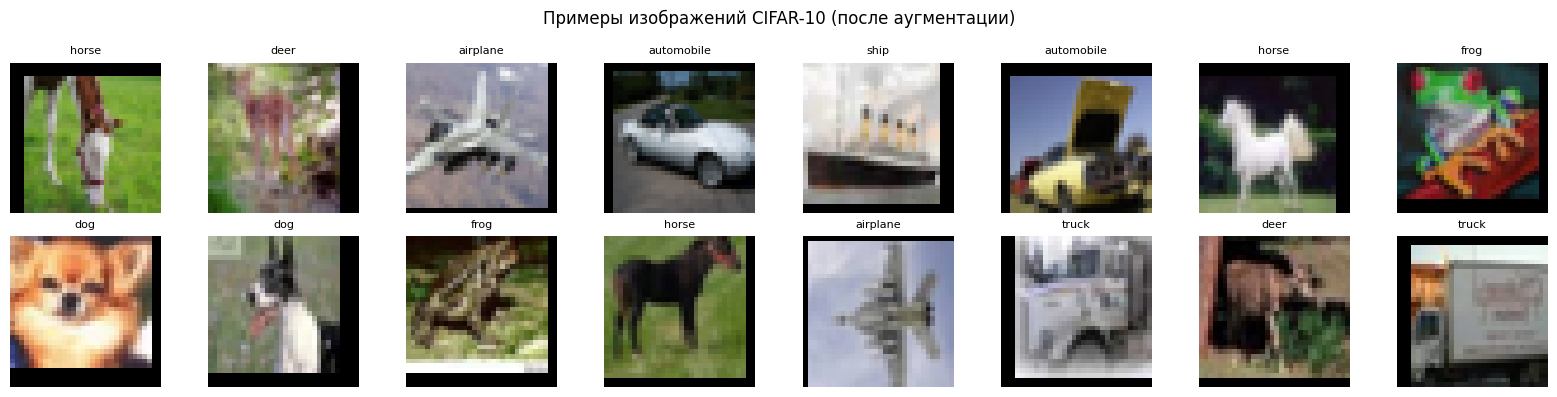

Форма батча: torch.Size([128, 3, 32, 32])  (N, C, H, W)


In [3]:
# Cell 3: CIFAR-10 data loading and preprocessing

# ImageNet-style normalization values pre-computed for CIFAR-10
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Download / load
# We keep two train-set views: augmented for optimization, deterministic for validation.
full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=True, download=True, transform=train_transform
)
full_train_eval_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=True, download=True, transform=test_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=False, download=True, transform=test_transform
)

# Train / validation split
n_total = len(full_train_aug_dataset)
n_val   = int(n_total * CONFIG["val_fraction"])
n_train = n_total - n_val
indices = torch.randperm(n_total, generator=torch.Generator().manual_seed(CONFIG["seed"])).tolist()
val_indices = indices[:n_val]
train_indices = indices[n_val:]

train_dataset = Subset(full_train_aug_dataset, train_indices)
val_dataset = Subset(full_train_eval_dataset, val_indices)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True
)

print(f"Train: {n_train:,} | Val: {n_val:,} | Test: {len(test_dataset):,}")
print("Val transform: deterministic normalization only (no augmentation)")
print(f"Батчей в train_loader: {len(train_loader)}")

# ── Quick visual check ─────────────────────────────────────────────────────
def denormalize(img_tensor):
    """Reverse CIFAR-10 normalization for display."""
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[sample_labels[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Примеры изображений CIFAR-10 (после аугментации)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Форма батча: {sample_imgs.shape}  (N, C, H, W)")

## Архитектура LeNet-5 (адаптированная для CIFAR-10)

Оригинальный **LeNet-5** (LeCun, 1998) разработан для MNIST (1×28×28). Мы адаптируем его под CIFAR-10 (3×32×32):

```
Input (3×32×32)
  └─ Conv(kernel) → BN → ReLU → MaxPool(2)   # feature maps: C1×16×16
      └─ Conv(kernel) → BN → ReLU → MaxPool(2)  # feature maps: C2×8×8  (или меньше при kernel=7)
          └─ Conv(kernel) → BN → ReLU           # feature maps: C3×H×W
              └─ Flatten → FC(256) → ReLU → Dropout
                  └─ FC(10) → logits
```

**Ключевые блоки:**
- `Conv2d` — операция свёртки: обнаруживает локальные паттерны
- `BatchNorm2d` — нормализует активации, ускоряет обучение
- `MaxPool2d(2,2)` — уменьшает пространственный размер вдвое, добавляет инвариантность
- `Dropout` — случайно обнуляет нейроны, борется с переобучением

> При ядре 7×7 пространственный размер уменьшается быстрее — это учтено в автоматическом расчёте `fc_input_dim`.

In [4]:
# Cell 4: LeNet-5 model definition

class LeNet5(nn.Module):
    """
    LeNet-5 adapted for CIFAR-10 (3×32×32 input).
    Supports configurable kernel sizes (3, 5, 7).
    """

    def __init__(self, kernel_size: int = 3, num_classes: int = 10, dropout: float = 0.4):
        super().__init__()
        pad = kernel_size // 2  # 'same'-style padding

        # ── Feature extractor ────────────────────────────────────────────
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size, padding=pad, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),           # → 32×16×16

            # Block 2
            nn.Conv2d(32, 64, kernel_size, padding=pad, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),           # → 64×8×8

            # Block 3 (no pooling)
            nn.Conv2d(64, 128, kernel_size, padding=pad, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),        # → 128×8×8
        )

        # Dynamically compute FC input size
        self._fc_input_dim = self._get_fc_input_dim()

        # ── Classifier ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self._fc_input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _get_fc_input_dim(self) -> int:
        """Pass a dummy tensor through features to get the flattened size."""
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            out = self.features(dummy)
            return int(out.view(1, -1).shape[1])

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        return self.classifier(x)


# ── Inspect baseline model ───────────────────────────────────────────────
model = LeNet5(kernel_size=CONFIG["kernel_size"],
               num_classes=CONFIG["num_classes"]).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nFC input dim : {model._fc_input_dim}")
print(f"Всего параметров     : {total_params:,}")
print(f"Обучаемых параметров : {trainable_params:,}")

# Sanity-check forward pass
with torch.no_grad():
    dummy_out = model(torch.zeros(4, 3, 32, 32, device=DEVICE))
print(f"Выход модели: {dummy_out.shape}  (ожидается [4, 10])")

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU(inp

## Функции обучения и валидации

Выносим логику обучения в переиспользуемые функции:
- `train_epoch` — один проход по тренировочным данным с обновлением весов
- `evaluate` — вычисление loss и accuracy без обновления весов

Используем **AdamW** (Adam + weight decay) и **OneCycleLR** для эффективного расписания learning rate.

In [5]:
# Cell 5: Training and validation functions

def train_epoch(model, loader, optimizer, criterion, scaler, scheduler=None):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed-precision forward
        with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Validation/test pass. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total


def build_optimizer_scheduler(model, config, steps_per_epoch):
    """Create AdamW optimizer + OneCycleLR scheduler."""
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["lr"],
        epochs=config["epochs"],
        steps_per_epoch=steps_per_epoch,
        pct_start=0.3,
        anneal_strategy="cos",
    )
    return optimizer, scheduler


print("Функции train_epoch и evaluate определены.")

Функции train_epoch и evaluate определены.


## Основной цикл обучения

Запускаем обучение на `CONFIG["epochs"]` эпох. По окончании каждой эпохи:
1. Считаем loss и accuracy на train и val
2. Сохраняем лучшую модель по val accuracy
3. Логируем прогресс

После обучения загружаем best checkpoint и оцениваем на тестовой выборке.

In [6]:
# Cell 6: Training loop with metrics

def run_training(model, train_loader, val_loader, config, verbose=True):
    """
    Full training loop.
    Returns history dict with keys: train_loss, val_loss, train_acc, val_acc, lr.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    cfg = {**config, "epochs": config.get("epochs", config["epochs"])}
    optimizer, scheduler = build_optimizer_scheduler(model, cfg, len(train_loader))
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=(DEVICE.type == "cuda"))

    history = defaultdict(list)
    best_val_acc = 0.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, scheduler)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            elapsed = time.time() - t0
            print(
                f"Epoch {epoch:02d}/{cfg['epochs']} "
                f"| train loss {tr_loss:.4f} acc {tr_acc:.4f} "
                f"| val loss {vl_loss:.4f} acc {vl_acc:.4f} "
                f"| {elapsed:.0f}s"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return dict(history), best_val_acc


# ── Run baseline training ────────────────────────────────────────────────
print(f"Обучение LeNet-5 (kernel={CONFIG['kernel_size']}) на {CONFIG['epochs']} эпохах...\n")

model = LeNet5(kernel_size=CONFIG["kernel_size"],
               num_classes=CONFIG["num_classes"]).to(DEVICE)

history, best_val_acc = run_training(model, train_loader, val_loader, CONFIG)

# Final test evaluation
criterion_eval = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion_eval)

print(f"\nЛучшая val accuracy : {best_val_acc:.4f}")
print(f"Test accuracy       : {test_acc:.4f}")
print(f"Test loss           : {test_loss:.4f}")

Обучение LeNet-5 (kernel=3) на 15 эпохах...



Epoch 01/15 | train loss 2.0138 acc 0.3079 | val loss 1.6576 acc 0.4772 | 44s


Epoch 02/15 | train loss 1.7007 acc 0.4455 | val loss 1.4895 acc 0.5574 | 88s


Epoch 03/15 | train loss 1.5646 acc 0.5198 | val loss 1.3773 acc 0.6194 | 131s


Epoch 04/15 | train loss 1.4648 acc 0.5701 | val loss 1.3363 acc 0.6332 | 175s


...

Epoch 12/15 | train loss 1.1324 acc 0.7338 | val loss 1.0153 acc 0.7858 | 526s


Epoch 13/15 | train loss 1.1080 acc 0.7474 | val loss 1.0062 acc 0.7926 | 571s


Epoch 14/15 | train loss 1.0951 acc 0.7516 | val loss 0.9973 acc 0.7936 | 615s


Epoch 15/15 | train loss 1.0915 acc 0.7544 | val loss 0.9956 acc 0.7966 | 658s



Лучшая val accuracy : 0.7966
Test accuracy       : 0.7870
Test loss           : 0.6789


## Графики потерь и точности

**Loss curve** — если validation loss растёт, а train loss падает → переобучение.  
**Accuracy curve** — основная метрика качества.  
**Learning rate schedule** — как менялся lr во время обучения (OneCycleLR: вначале растёт, затем убывает).

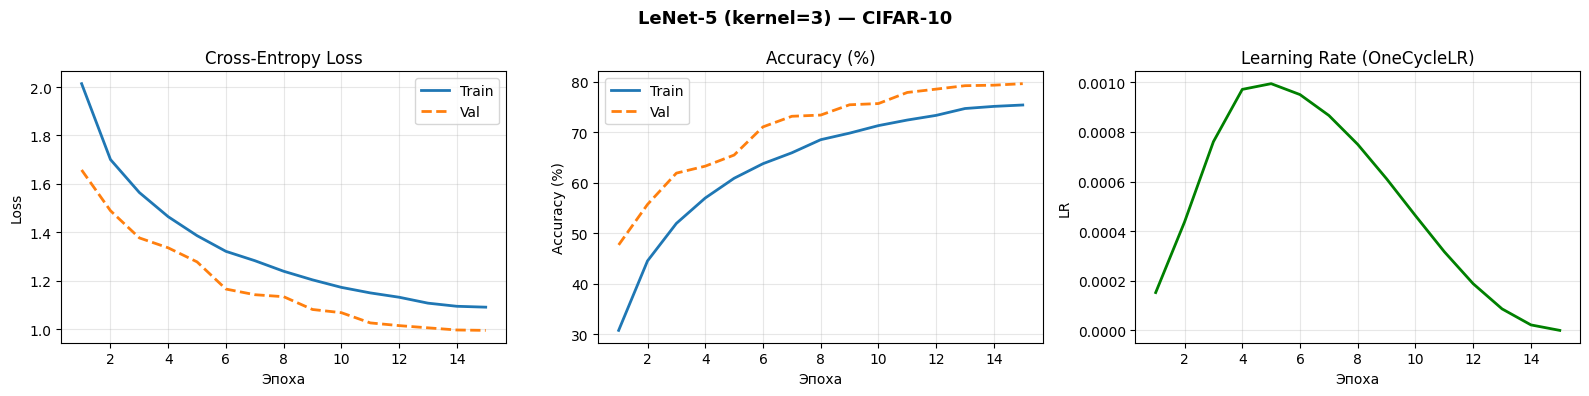

Лучшая val accuracy: 0.7966 на эпохе 15


In [7]:
# Cell 7: Loss/accuracy plots

def plot_history(history, title="LeNet-5 обучение", save_name="lenet_history.png"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Loss
    ax = axes[0]
    ax.plot(epochs, history["train_loss"], label="Train", linewidth=2)
    ax.plot(epochs, history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title("Cross-Entropy Loss")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train", linewidth=2)
    ax.plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title("Accuracy (%)")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.grid(alpha=0.3)

    # Learning rate
    ax = axes[2]
    ax.plot(epochs, history["lr"], color="green", linewidth=2)
    ax.set_title("Learning Rate (OneCycleLR)")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("LR")
    ax.grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=120, bbox_inches='tight')
    plt.show()

    best_ep = int(np.argmax(history["val_acc"])) + 1
    print(f"Лучшая val accuracy: {max(history['val_acc']):.4f} на эпохе {best_ep}")


plot_history(
    history,
    title=f"LeNet-5 (kernel={CONFIG['kernel_size']}) — CIFAR-10",
    save_name='lenet5_training_curves.png',
)

## Визуализация карт признаков (Feature Maps)

**Карты признаков** — выходы промежуточных свёрточных слоёв для конкретного входного изображения. Они показывают, какие паттерны «видит» сеть на каждом уровне абстракции:
- **Block 1** — края, текстуры, цвета
- **Block 2** — части объектов (углы, формы)
- **Block 3** — более абстрактные признаки

Используем **forward hooks** — колбэки, которые PyTorch вызывает после каждого слоя, позволяя перехватить промежуточные активации без изменения кода модели.

Визуализация карт признаков (OpenCV: True)


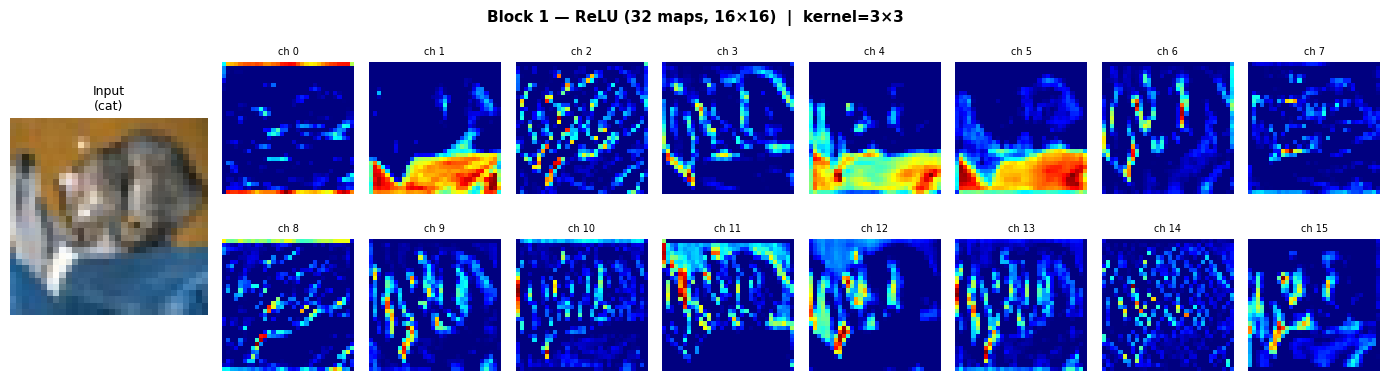

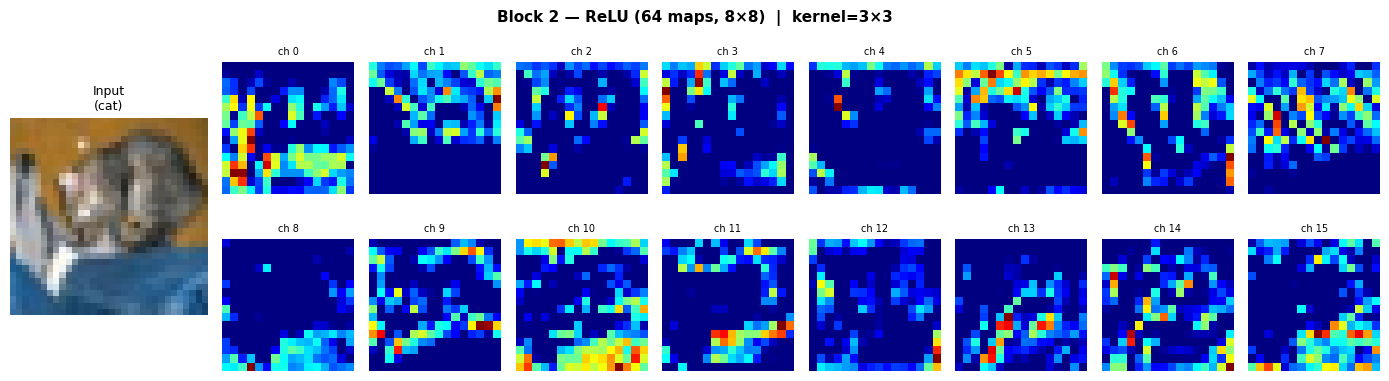

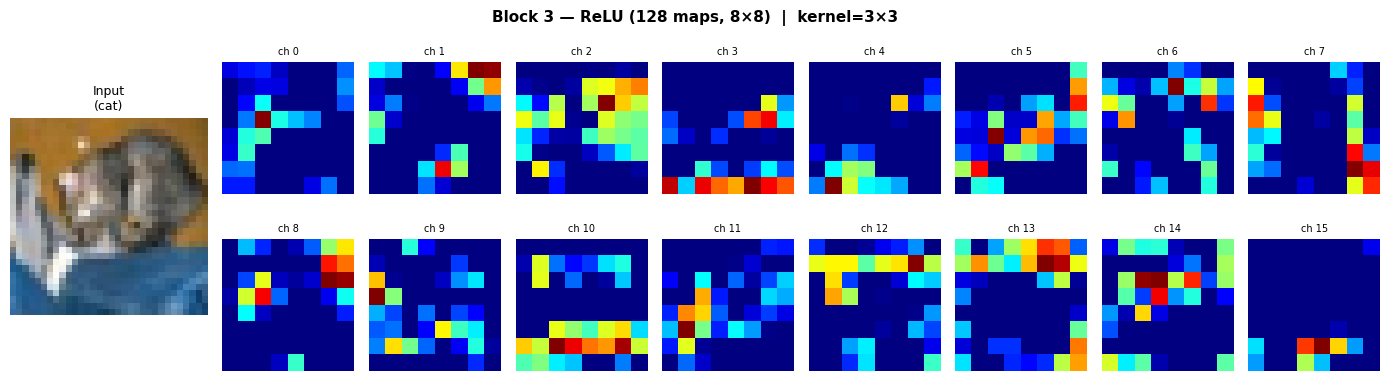

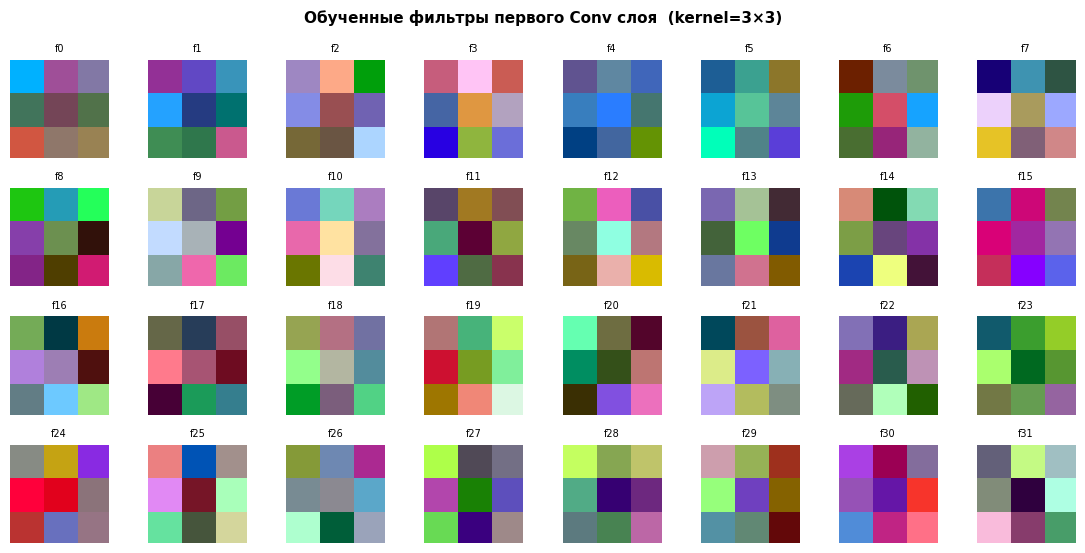

In [8]:
# Cell 8: Feature maps visualization (hooks to capture intermediate activations)

class ActivationRecorder:
    """
    Registers forward hooks on target layers and stores their outputs.
    Usage:
        recorder = ActivationRecorder(model, layer_names)
        out = model(x)
        acts = recorder.activations
        recorder.remove()  # always clean up
    """

    def __init__(self, model, layer_names):
        self.activations = {}
        self._hooks = []
        for name, module in model.named_modules():
            if name in layer_names:
                hook = module.register_forward_hook(self._make_hook(name))
                self._hooks.append(hook)

    def _make_hook(self, name):
        def hook(module, input, output):
            self.activations[name] = output.detach().cpu()
        return hook

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()


def visualize_feature_maps(model, images, labels, n_maps=16, use_cv2=False):
    """
    Capture and display feature maps from 3 convolutional blocks for a single image.
    If use_cv2=True and OpenCV is available, applies colormap for richer visualization.
    """
    # Identify ReLU layers after each block (indices 2, 6, 10 in features Sequential)
    target_layers = {
        "features.2" : "Block 1 — ReLU (32 maps, 16×16)",
        "features.6" : "Block 2 — ReLU (64 maps, 8×8)",
        "features.10": "Block 3 — ReLU (128 maps, 8×8)",
    }

    recorder = ActivationRecorder(model, list(target_layers.keys()))
    model.eval()
    with torch.no_grad():
        img_tensor = images[0:1].to(DEVICE)
        _ = model(img_tensor)
    recorder.remove()

    # Show original image
    orig = denormalize(images[0]).permute(1, 2, 0).numpy()
    true_label = CIFAR10_CLASSES[labels[0].item()]

    for layer_key, layer_title in target_layers.items():
        if layer_key not in recorder.activations:
            print(f"[WARN] слой {layer_key} не найден")
            continue

        act = recorder.activations[layer_key][0]  # shape: (C, H, W)
        n_show = min(n_maps, act.shape[0])
        cols = 8
        rows = (n_show + cols - 1) // cols

        fig = plt.figure(figsize=(cols * 1.5 + 2, rows * 1.5 + 1))
        gs = gridspec.GridSpec(rows, cols + 1, figure=fig,
                               width_ratios=[1.5] + [1] * cols)

        # Original image in first column
        ax0 = fig.add_subplot(gs[:, 0])
        ax0.imshow(orig)
        ax0.set_title(f"Input\n({true_label})", fontsize=9)
        ax0.axis("off")

        for i in range(n_show):
            r, c = divmod(i, cols)
            ax = fig.add_subplot(gs[r, c + 1])
            fmap = act[i].numpy()

            if use_cv2 and HAS_CV2:
                # Normalize to 0-255 and apply COLORMAP_JET
                fmap_norm = cv2.normalize(fmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
                fmap_colored = cv2.applyColorMap(fmap_norm, cv2.COLORMAP_JET)
                fmap_rgb = cv2.cvtColor(fmap_colored, cv2.COLOR_BGR2RGB)
                ax.imshow(fmap_rgb)
            else:
                ax.imshow(fmap, cmap="viridis")

            ax.set_title(f"ch {i}", fontsize=7)
            ax.axis("off")

        fig.suptitle(f"{layer_title}  |  kernel={CONFIG['kernel_size']}×{CONFIG['kernel_size']}",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"feature_maps_{layer_key.replace('.', '_')}.png", dpi=120, bbox_inches='tight')
    plt.show()


# Grab a test batch and visualize
test_images, test_labels = next(iter(test_loader))

print(f"Визуализация карт признаков (OpenCV: {HAS_CV2})")
visualize_feature_maps(model, test_images, test_labels, n_maps=16, use_cv2=HAS_CV2)


# ── Bonus: visualize learned conv filters ───────────────────────────────
def visualize_conv_filters(model, use_cv2=False):
    """Display first-layer convolutional filters (3-channel kernels)."""
    first_conv = model.features[0]  # nn.Conv2d
    weights = first_conv.weight.detach().cpu()  # (out_ch, 3, kH, kW)

    n_filters = min(32, weights.shape[0])
    cols = 8
    rows = (n_filters + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
    axes = axes.flat

    for i in range(n_filters):
        filt = weights[i].permute(1, 2, 0).numpy()  # (H, W, 3)
        # Normalize each filter independently for display
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)

        if use_cv2 and HAS_CV2 and filt.shape[0] > 1:
            # Resize for better visibility
            filt_big = cv2.resize(
                (filt * 255).astype(np.uint8),
                (32, 32), interpolation=cv2.INTER_NEAREST
            )
            axes[i].imshow(filt_big)
        else:
            axes[i].imshow(filt)

        axes[i].axis("off")
        axes[i].set_title(f"f{i}", fontsize=7)

    for j in range(n_filters, len(list(axes))):
        list(axes)[j].axis("off")

    fig.suptitle(f"Обученные фильтры первого Conv слоя  (kernel={CONFIG['kernel_size']}×{CONFIG['kernel_size']})",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'conv1_filters.png', dpi=120, bbox_inches='tight')
    plt.show()


visualize_conv_filters(model, use_cv2=HAS_CV2)

## Сравнение размеров ядра свёртки: 3×3 vs 5×5 vs 7×7

**Размер ядра** — ключевой гиперпараметр свёрточного слоя:

| Ядро | Рецептивное поле | Параметры (вход 3, выход 32) | Особенности |
|------|-----------------|------------------------------|-------------|
| 3×3  | Локальный        | 3×32×9 = 864                 | Точнее, быстрее, стандарт |
| 5×5  | Средний          | 3×32×25 = 2400               | Баланс |
| 7×7  | Широкий          | 3×32×49 = 4704               | Больше контекста, больше памяти |

> Два слоя 3×3 имеют то же рецептивное поле, что один 5×5, но меньше параметров — поэтому современные архитектуры предпочитают 3×3.

Мы обучим три модели в **одинаковых условиях** и сравним:
1. Validation accuracy как основную метрику выбора ядра
2. Test accuracy как финальную контрольную метрику после выбора по validation
3. Скорость обучения (loss convergence)
4. Стабильность (разброс loss по эпохам)


  Ядро 3×3  —  обучение 10 эпох
  Параметров: 2,193,450


Epoch 01/10 | train loss 1.9964 acc 0.3113 | val loss 1.6300 acc 0.4834 | 45s


Epoch 02/10 | train loss 1.6843 acc 0.4540 | val loss 1.4916 acc 0.5594 | 93s


Epoch 03/10 | train loss 1.5310 acc 0.5361 | val loss 1.3249 acc 0.6426 | 138s


Epoch 04/10 | train loss 1.4133 acc 0.5952 | val loss 1.2355 acc 0.6820 | 185s


...

Epoch 07/10 | train loss 1.2171 acc 0.6931 | val loss 1.1407 acc 0.7228 | 474s


Epoch 08/10 | train loss 1.1631 acc 0.7165 | val loss 1.0655 acc 0.7594 | 542s


Epoch 09/10 | train loss 1.1264 acc 0.7351 | val loss 1.0384 acc 0.7698 | 610s


Epoch 10/10 | train loss 1.0989 acc 0.7477 | val loss 1.0318 acc 0.7738 | 678s


  Best val acc: 0.7738  |  Test acc: 0.7704


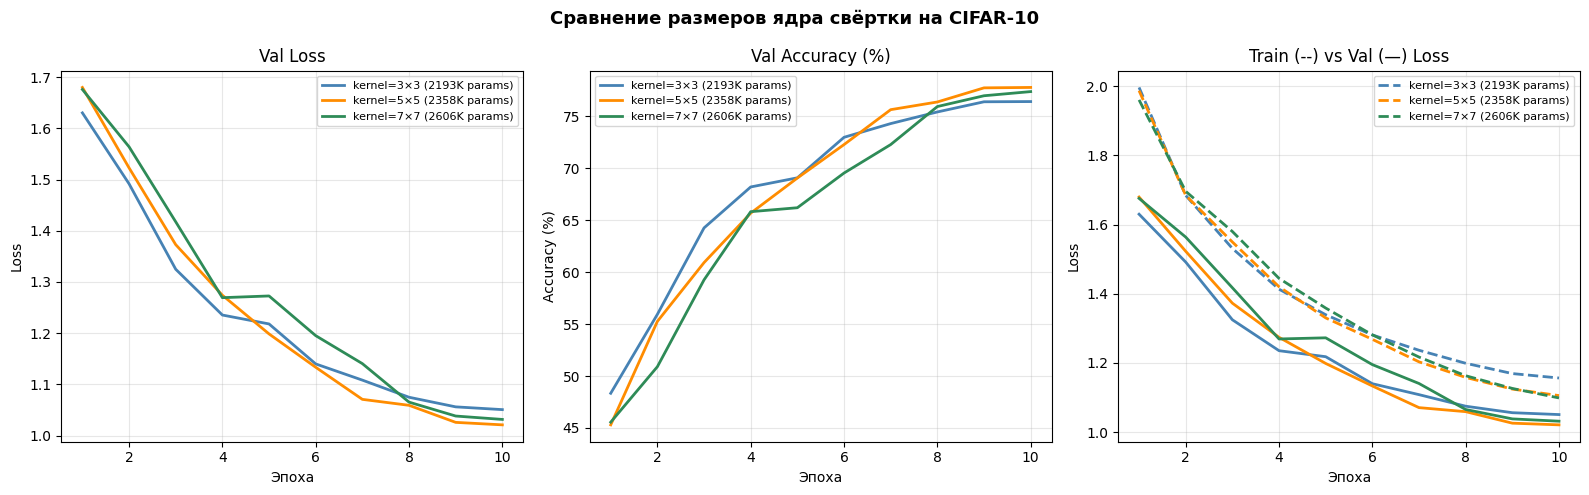


──────────────────────────────────────────────────────────────
    Ядро |    Параметры | Best Val Acc |   Test Acc
──────────────────────────────────────────────────────────────
    3×3  |    2,193,450 |       0.7642 |     0.7638
    5×5  |    2,358,826 |       0.7778 |     0.7773
    7×7  |    2,606,890 |       0.7738 |     0.7704
──────────────────────────────────────────────────────────────


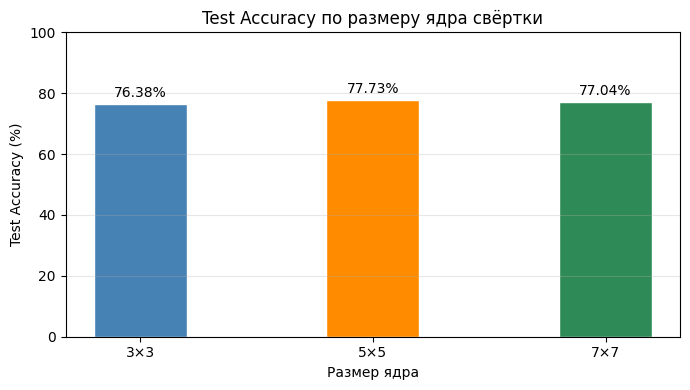

In [9]:
# Cell 9: Kernel size comparison experiment (3x3 vs 5x5 vs 7x7)

compare_config = {**CONFIG, "epochs": CONFIG["compare_epochs"]}
kernel_results = {}  # kernel_size -> {history, test_acc, n_params}

for ks in CONFIG["kernel_sizes"]:
    print(f"\n{'='*55}")
    print(f"  Ядро {ks}×{ks}  —  обучение {compare_config['epochs']} эпох")
    print(f"{'='*55}")

    torch.manual_seed(CONFIG["seed"])  # same init conditions
    m = LeNet5(kernel_size=ks, num_classes=CONFIG["num_classes"]).to(DEVICE)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  Параметров: {n_params:,}")

    hist, best_val = run_training(m, train_loader, val_loader, compare_config)
    _, t_acc = evaluate(m, test_loader, nn.CrossEntropyLoss())

    kernel_results[ks] = {
        "history"  : hist,
        "best_val" : best_val,
        "test_acc" : t_acc,
        "n_params" : n_params,
        "model"    : m,
    }
    print(f"  Best val acc: {best_val:.4f}  |  Test acc: {t_acc:.4f}")


# ── Side-by-side plots ───────────────────────────────────────────────────
epochs_x = range(1, compare_config["epochs"] + 1)
colors = {3: "steelblue", 5: "darkorange", 7: "seagreen"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ks, res in kernel_results.items():
    h = res["history"]
    c = colors[ks]
    label = f"kernel={ks}×{ks} ({res['n_params']//1000}K params)"

    axes[0].plot(epochs_x, h["val_loss"],
                 color=c, label=label, linewidth=2)
    axes[1].plot(epochs_x, [a * 100 for a in h["val_acc"]],
                 color=c, label=label, linewidth=2)
    axes[2].plot(epochs_x, h["train_loss"],
                 color=c, label=label, linewidth=2, linestyle="--")
    axes[2].plot(epochs_x, h["val_loss"],
                 color=c, linewidth=2)

axes[0].set_title("Val Loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title("Val Accuracy (%)")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].set_title("Train (--) vs Val (—) Loss")
axes[2].set_xlabel("Эпоха")
axes[2].set_ylabel("Loss")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.suptitle("Сравнение размеров ядра свёртки на CIFAR-10",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kernel_size_comparison_curves.png', dpi=120, bbox_inches='tight')
plt.show()


# ── Summary table ────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print(f"{'Ядро':>8} | {'Параметры':>12} | {'Best Val Acc':>12} | {'Test Acc':>10}")
print("─" * 62)
for ks, res in kernel_results.items():
    print(
        f"{ks:>5}×{ks:<2} | {res['n_params']:>12,} | "
        f"{res['best_val']:>12.4f} | {res['test_acc']:>10.4f}"
    )
print("─" * 62)


# ── Bar chart: test accuracy ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ks_list = list(kernel_results.keys())
test_accs = [kernel_results[ks]["test_acc"] * 100 for ks in ks_list]
bars = ax.bar(
    [f"{k}×{k}" for k in ks_list], test_accs,
    color=[colors[k] for k in ks_list], width=0.4, edgecolor="white"
)
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=10)
ax.set_ylim(0, 100)
ax.set_xlabel("Размер ядра")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy по размеру ядра свёртки")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kernel_size_test_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

## Итоги и выводы

### Что мы реализовали

1. **Простая CNN в стиле LeNet-5 для CIFAR-10** — три блока `Conv2d → BatchNorm → ReLU → MaxPool`, полносвязный классификатор
2. **Современный pipeline обучения**: AdamW + OneCycleLR + mixed precision + gradient clipping
3. **Карты признаков** — визуализация через forward hooks показывает, как сеть видит изображение на разных уровнях
4. **Сравнение ядер** 3×3 vs 5×5 vs 7×7 в контролируемых условиях

### Наблюдения

| Ядро | Плюсы | Минусы |
|------|-------|--------|
| **3×3** | Меньше параметров, быстрее считается | Меньше локальный контекст |
| **5×5** | Больше контекста при умеренном росте параметров | Медленнее и тяжелее по памяти |
| **7×7** | Самое широкое рецептивное поле | Ещё больше параметров и выше вычислительная цена |

> Итоговый выбор ядра нужно делать по **validation accuracy**, а test accuracy использовать только для финальной проверки.

### Куда двигаться дальше

- **ResNet** — остаточные соединения решают проблему деградации при глубоком стеке
- **EfficientNet** — масштабирование по ширине, глубине и разрешению одновременно
- **Transfer learning** — использование предобученных весов (ImageNet) для ускорения обучения
- **Data augmentation** — Cutout, CutMix, RandAugment для повышения accuracy
- **Знание дистилляции** — обучение маленькой сети с учителем

In [10]:
# Cell 10: Summary / conclusions

print("=" * 60)
print("ИТОГИ ЭКСПЕРИМЕНТА")
print("=" * 60)

print(f"\nБазовая модель LeNet-5 (kernel={CONFIG['kernel_size']}x{CONFIG['kernel_size']})")
print(f"  Эпох обучения     : {CONFIG['epochs']}")
print(f"  Параметров        : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Test Accuracy     : {test_acc * 100:.2f}%")
print(f"  Test Loss         : {test_loss:.4f}")

print(f"\nСравнение ядер ({compare_config['epochs']} эпох):")
best_ks = max(kernel_results, key=lambda k: kernel_results[k]["best_val"])
best_test_ks = max(kernel_results, key=lambda k: kernel_results[k]["test_acc"])
for ks, res in kernel_results.items():
    marker = " <-- лучшее по val" if ks == best_ks else ""
    print(f"  kernel {ks}x{ks}: val_acc={res['best_val']*100:.2f}%  "
          f"test_acc={res['test_acc']*100:.2f}%  params={res['n_params']//1000}K{marker}")

print("\nВыводы:")
print("  1. Свёрточные сети значительно эффективнее MLP для изображений")
print("  2. BatchNorm + ReLU — стандартный строительный блок современных CNN")
print("  3. Карты признаков наглядно показывают иерархию обнаруживаемых паттернов")
print(f"  4. Лучшее ядро по validation accuracy в этом прогоне: {best_ks}x{best_ks}")
if best_test_ks != best_ks:
    print(f"     Test-лидер ({best_test_ks}x{best_test_ks}) отличается, но гиперпараметр выбираем по validation")
print("  5. OneCycleLR обеспечивает быструю сходимость и хорошую generalization")
print("=" * 60)

ИТОГИ ЭКСПЕРИМЕНТА

Базовая модель LeNet-5 (kernel=3x3)
  Эпох обучения     : 15
  Параметров        : 2,193,450
  Test Accuracy     : 78.70%
  Test Loss         : 0.6789

Сравнение ядер (10 эпох):
  kernel 3x3: val_acc=76.42%  test_acc=76.38%  params=2193K
  kernel 5x5: val_acc=77.78%  test_acc=77.73%  params=2358K <-- лучшее по val
  kernel 7x7: val_acc=77.38%  test_acc=77.04%  params=2606K

Выводы:
  1. Свёрточные сети значительно эффективнее MLP для изображений
  2. BatchNorm + ReLU — стандартный строительный блок современных CNN
  3. Карты признаков наглядно показывают иерархию обнаруживаемых паттернов
  4. Лучшее ядро по validation accuracy в этом прогоне: 5x5
  5. OneCycleLR обеспечивает быструю сходимость и хорошую generalization
